# Import libraries

In [1]:
import pandas as pd 
import numpy as np
import joblib

from scipy.sparse import load_npz, hstack
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score
from scipy.stats import loguniform

from model_utils import train_model, classify_analysis, error_analysis
from preprocessing_utils import add_shared_features, tokens_to_text

In [2]:
PROCESS_DATA_PATH = "preprocess_data"
MODEL_PATH = "models"
RANDOM_STATE = 42

DROP_COLUMNS = [
    "qid1",
    "qid2",
    "question1",
    "question2",
    "question1_tokens",
    "question2_tokens",
    "split",
    "question1_clean",
    "question2_clean",
    "is_duplicate"
]

EMBEDDING_FEATURES = [
    "embedding_cosine",
    "embedding_euclidean"
]

In [3]:
param_dist = {
    "C": loguniform(1e-3, 1e2),
    "solver": ["lbfgs", "saga", "liblinear"],
    "class_weight": [None, "balanced"]
}

# TF-IDF

## With stopwords

### Data Loading

#### Data

In [4]:
train_df_sw = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_sw_tf_idf.parquet")
val_df_sw = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_sw_tf_idf.parquet")

train_df_sw.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,"[what, be, practical, management, and, what, b...","[what, be, the, practical, aspect, of, strateg...",5,0.555556,0.833333,1,7,what be practical management and what be strat...,what be the practical aspect of strategic mana...,0.500282
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,"[how, useful, be, makeuseof, answer]","[be, there, any, q, a, site, that, be, not, ya...",2,0.117647,0.400000,11,46,how useful be makeuseof answer,be there any q a site that be not yahoo answer...,0.060493
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[which, be, the, best, place, to, reside, in, ...","[which, ia, the, best, place, to, visit, in, i...",7,0.538462,0.777778,2,9,which be the best place to reside in india and...,which ia the best place to visit in india,0.318665


#### TF-IDF

In [5]:
train_sw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/train_sw_tf_idf_q1_vec.npz")
train_sw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/train_sw_tf_idf_q2_vec.npz")

val_sw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/val_sw_tf_idf_q1_vec.npz")
val_sw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/val_sw_tf_idf_q2_vec.npz")

train_sw_q1_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4671378 stored elements and shape (261296, 215129)>

### Design matrix and target

In [6]:
X_train_sw = hstack([train_sw_q1_vec, train_sw_q2_vec])
X_val_sw = hstack([val_sw_q1_vec, val_sw_q2_vec])

X_train_sw

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9429335 stored elements and shape (261296, 430258)>

In [7]:
y_train_sw = train_df_sw['is_duplicate']
y_val_sw = val_df_sw['is_duplicate']

y_train_sw.head(3)

0    0
1    0
2    0
Name: is_duplicate, dtype: int64

### Model using RandomizedSearchCV

In [10]:
search_sw = RandomizedSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

In [11]:
train_model(search_sw, X_train_sw, y_train_sw)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Training time: 395.55 seconds


(RandomizedSearchCV(cv=5,
                    estimator=LogisticRegression(max_iter=1000, random_state=42),
                    n_iter=20, n_jobs=-1,
                    param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                                         'class_weight': [None, 'balanced'],
                                         'solver': ['lbfgs', 'liblinear',
                                                    'saga']},
                    random_state=42, scoring='f1', verbose=2),
 395.54648499994073)

In [12]:
best_params_sw = search_sw.best_params_
print(best_params_sw)

{'solver': 'saga', 'class_weight': 'balanced', 'C': 10}


In [13]:
print(search_sw.best_score_)

0.711710560268274


In [14]:
best_model_sw = search_sw.best_estimator_

In [17]:
joblib.dump(best_model_sw, f"{MODEL_PATH}/best_logistic_model_sw.joblib")

['models/best_logistic_model_sw.joblib']

#### Evaluation

Training
Log Loss      : 0.1652
ROC-AUC       : 0.9956
F1-score      : 0.9624
Inference time: 0.0664 s


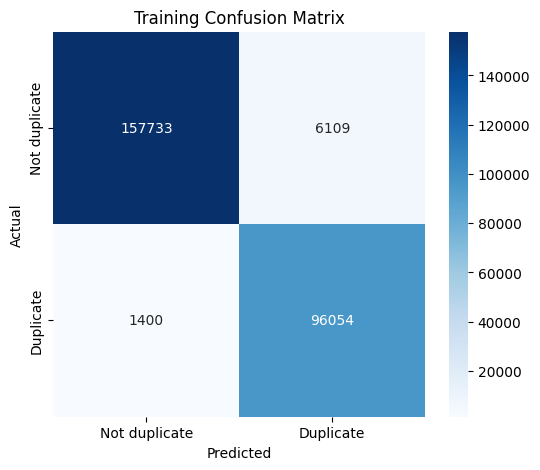


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.98    163842
           1       0.94      0.99      0.96     97454

    accuracy                           0.97    261296
   macro avg       0.97      0.97      0.97    261296
weighted avg       0.97      0.97      0.97    261296

Validation
Log Loss      : 0.6641
ROC-AUC       : 0.7250
F1-score      : 0.5447
Inference time: 0.0234 s


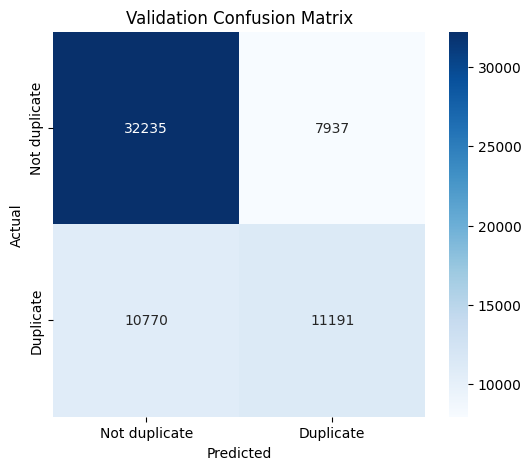


Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.80      0.78     40172
           1       0.59      0.51      0.54     21961

    accuracy                           0.70     62133
   macro avg       0.67      0.66      0.66     62133
weighted avg       0.69      0.70      0.69     62133



{'log_loss': 0.6640543454913763,
 'roc_auc': 0.7249924670485829,
 'f1_score': 0.5447199980530069,
 'inference_time': 0.023424600018188357}

In [18]:
classify_analysis(y_train_sw, X_train_sw, best_model_sw, 'Training')
classify_analysis(y_val_sw, X_val_sw, best_model_sw, 'Validation')

#### Error analysis

In [19]:
train_errors_sw = error_analysis(train_df_sw, X_train_sw, best_model_sw)

print("False Positive training examples")
display(train_errors_sw["fp"].head())

print("False Negative training examples")
display(train_errors_sw["fn"].head())

Error Analysis
TP : 96054
TN : 157733
FP : 6109
FN : 1400
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[which, be, the, best, place, to, reside, in, ...","[which, ia, the, best, place, to, visit, in, i...",7,0.538462,0.777778,2,9,which be the best place to reside in india and...,which ia the best place to visit in india,0.318665,1,0.699218
20,197537,65750,How do I download free movies from torrent?,How do I download from torrent?,0,train,"[how, do, i, download, free, movie, from, torr...","[how, do, i, download, from, torrent]",6,0.750000,1.000000,2,12,how do i download free movie from torrent,how do i download from torrent,0.592177,1,0.569291
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,"[which, language, do, you, think, be, the, mos...","[which, be, the, most, difficult, language, of...",7,0.466667,0.700000,2,11,which language do you think be the most diffic...,which be the most difficult language of the wo...,0.402059,1,0.535936
49,432554,432555,What is the best book to read on investment st...,What are some good books on investment?,0,train,"[what, be, the, best, book, to, read, on, inve...","[what, be, some, good, book, on, investment]",5,0.416667,0.714286,3,16,what be the best book to read on investment st...,what be some good book on investment,0.412511,1,0.544464
83,72064,72065,Did India won a single medal in Rio Olympics 2...,How many medals did India won in Olympic 2016?,0,train,"[do, india, won, a, single, medal, in, rio, ol...","[how, many, medal, do, india, won, in, olympic...",6,0.461538,0.666667,1,4,do india won a single medal in rio olympics 2016,how many medal do india won in olympic 2016,0.398923,1,0.612732


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
181,446830,257938,What are rent averages in New York City by bor...,What are the rent averages in New York City by...,1,train,"[what, be, rent, average, in, new, york, city,...","[what, be, the, rent, average, in, new, york, ...",13,0.928571,1.000000,1,4,what be rent average in new york city by borou...,what be the rent average in new york city by b...,0.914031,0,0.456930
241,325341,151212,How can i know how many devices are connected ...,How can I find out how many devices are connec...,1,train,"[how, can, i, know, how, many, device, be, con...","[how, can, i, find, out, how, many, device, be...",10,0.714286,0.833333,0,4,how can i know how many device be connect to m...,how can i find out how many device be connect ...,0.743201,0,0.437815
390,41119,41120,What does it mean to commit?,What does it mean to be committed?,1,train,"[what, do, it, mean, to, commit]","[what, do, it, mean, to, be, commit]",6,0.857143,1.000000,1,6,what do it mean to commit,what do it mean to be commit,0.718290,0,0.452425
792,140742,300524,What are the pros and cons of dams?,What are dams? What are the pros and cons?,1,train,"[what, be, the, pro, and, con, of, dam]","[what, be, dams, what, be, the, pro, and, con]",6,0.666667,0.857143,1,7,what be the pro and con of dam,what be dams what be the pro and con,0.486110,0,0.494203
845,424984,424985,Is it bad to not want to have kids?,Is it okay if I don't want to have kids?,1,train,"[be, it, bad, to, not, want, to, have, kid]","[be, it, okay, if, i, do, not, want, to, have,...",7,0.583333,0.875000,2,5,be it bad to not want to have kid,be it okay if i do not want to have kid,0.561473,0,0.317286


In [20]:
val_errors_sw = error_analysis(val_df_sw, X_val_sw, best_model_sw)

print("False Positive validation examples")
display(val_errors_sw["fp"].head())

print("False Negative validation examples")
display(val_errors_sw["fn"].head())

Error Analysis
TP : 11191
TN : 32235
FP : 7937
FN : 10770
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
5,45508,303505,When did you join Quora?,Why did I join Quora?,0,val,"[when, do, you, join, quora]","[why, do, i, join, quora]",3,0.428571,0.600000,0,3,when do you join quora,why do i join quora,0.547603,1,0.723030
20,346197,537204,What is the mileage of Royal Enfield Himalayan...,Which handlebar will be most comfortable for l...,0,val,"[what, be, the, mileage, of, royal, enfield, h...","[which, handlebar, will, be, most, comfortable...",4,0.200000,0.400000,4,28,what be the mileage of royal enfield himalayan...,which handlebar will be most comfortable for l...,0.365857,1,0.545119
43,483191,225770,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0,val,"[what, be, it, like, to, live, on, an, israeli...","[what, be, it, like, to, live, in, an, israeli...",10,0.714286,1.000000,4,17,what be it like to live on an israeli settlement,what be it like to live in an israeli settleme...,0.656330,1,0.717047
44,358687,358688,What does Nelson Mandela mean to you?,What was Nelson Mandela like in person?,0,val,"[what, do, nelson, mandela, mean, to, you]","[what, be, nelson, mandela, like, in, person]",3,0.272727,0.428571,0,2,what do nelson mandela mean to you,what be nelson mandela like in person,0.535791,1,0.664292
48,30745,29667,Why do most café startups fail?,Why do so many startups fail?,0,val,"[why, do, most, café, startup, fail]","[why, do, so, many, startup, fail]",4,0.500000,0.666667,0,2,why do most café startup fail,why do so many startup fail,0.534905,1,0.681328


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,"[how, can, i, open, a, ppf, account, and, what...","[what, be, ppf, account]",4,0.333333,1.000000,8,36,how can i open a ppf account and what be it be...,what be ppf account,0.559547,0,0.433476
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"[what, be, the, sahara, and, how, do, the, ave...","[what, be, the, sahara, and, how, do, the, ave...",14,0.823529,0.933333,1,3,what be the sahara and how do the average temp...,what be the sahara and how do the average temp...,0.753968,0,0.049078
10,356289,356290,What is a submersible pump? What purpose does ...,What is a submersible pump?,1,val,"[what, be, a, submersible, pump, what, purpose...","[what, be, a, submersible, pump]",5,0.555556,1.000000,5,28,what be a submersible pump what purpose do it ...,what be a submersible pump,0.431921,0,0.117483
18,179589,219828,Which is best choice for newbies Honda hornet ...,I am looking to buy new bike. Suzuki gixxer 15...,1,val,"[which, be, best, choice, for, newbie, honda, ...","[i, be, look, to, buy, new, bike, suzuki, gixx...",9,0.450000,0.692308,5,15,which be best choice for newbie honda hornet 1...,i be look to buy new bike suzuki gixxer 155 or...,0.522724,0,0.040226
24,247714,394432,"Are there any free online resources (courses, ...",Where can I do an online business analyst cert...,1,val,"[be, there, any, free, online, resource, cours...","[where, can, i, do, an, online, business, anal...",5,0.238095,0.454545,6,65,be there any free online resource course video...,where can i do an online business analyst cert...,0.284768,0,0.101769


## Without stopwords

### Data Loading

#### Data

In [21]:
train_df_nosw = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_nosw_tf_idf.parquet")
val_df_nosw = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_nosw_tf_idf.parquet")

train_df_nosw.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,"[practical, management, strategic, management]","[practical, aspect, strategic, management]",3,0.750000,1.000000,0,7,practical management strategic management,practical aspect strategic management,0.878978
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,"[useful, makeuseof, answer]","[q, site, yahoo, answer, hate, speech, allow]",1,0.111111,0.333333,4,46,useful makeuseof answer,q site yahoo answer hate speech allow,0.128030
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[best, place, reside, india]","[ia, best, place, visit, india]",3,0.500000,0.750000,1,9,best place reside india,ia best place visit india,0.225184


#### TF-IDF

In [23]:
train_nosw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/train_nosw_tf_idf_q1_vec.npz")
train_nosw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/train_nosw_tf_idf_q2_vec.npz")

val_nosw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/val_nosw_tf_idf_q1_vec.npz")
val_nosw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/val_nosw_tf_idf_q2_vec.npz")

train_nosw_q1_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2112912 stored elements and shape (261296, 172154)>

### Design matrix and target

In [24]:
X_train_nosw = hstack([train_nosw_q1_vec, train_nosw_q2_vec])
X_val_nosw = hstack([val_nosw_q1_vec, val_nosw_q2_vec])

X_train_nosw

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4252270 stored elements and shape (261296, 344308)>

In [25]:
y_train_nosw = train_df_nosw['is_duplicate']
y_val_nosw = val_df_nosw['is_duplicate']

y_train_nosw.head(3)

0    0
1    0
2    0
Name: is_duplicate, dtype: int64

### Model using RandomizedSearchCV

In [26]:
search_nosw = RandomizedSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

In [27]:
train_model(search_nosw, X_train_nosw, y_train_nosw)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Training time: 254.91 seconds


(RandomizedSearchCV(cv=5,
                    estimator=LogisticRegression(max_iter=1000, random_state=42),
                    n_iter=20, n_jobs=-1,
                    param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                                         'class_weight': [None, 'balanced'],
                                         'solver': ['lbfgs', 'liblinear',
                                                    'saga']},
                    random_state=42, scoring='f1', verbose=2),
 254.91115109995008)

In [28]:
best_params_nosw = search_nosw.best_params_
print(best_params_nosw)

{'solver': 'saga', 'class_weight': 'balanced', 'C': 10}


In [29]:
print(search_nosw.best_score_)

0.7041178014465258


In [30]:
best_model_nosw = search_nosw.best_estimator_

In [31]:
joblib.dump(best_model_nosw, f"{MODEL_PATH}/best_logistic_model_nosw.joblib")

['models/best_logistic_model_nosw.joblib']

#### Evaluation

Training
Log Loss      : 0.1810
ROC-AUC       : 0.9924
F1-score      : 0.9485
Inference time: 0.0517 s


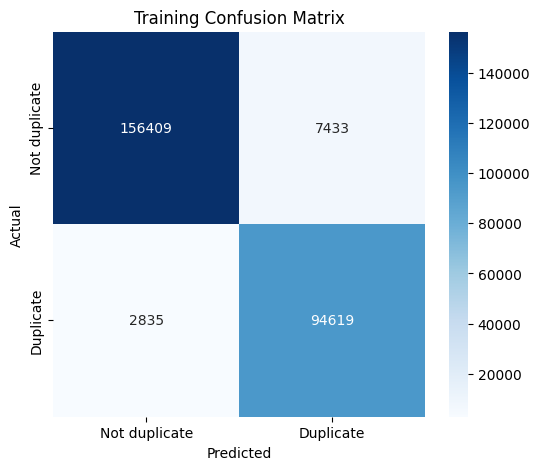


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.97    163842
           1       0.93      0.97      0.95     97454

    accuracy                           0.96    261296
   macro avg       0.95      0.96      0.96    261296
weighted avg       0.96      0.96      0.96    261296

Validation
Log Loss      : 0.6911
ROC-AUC       : 0.7004
F1-score      : 0.5073
Inference time: 0.0085 s


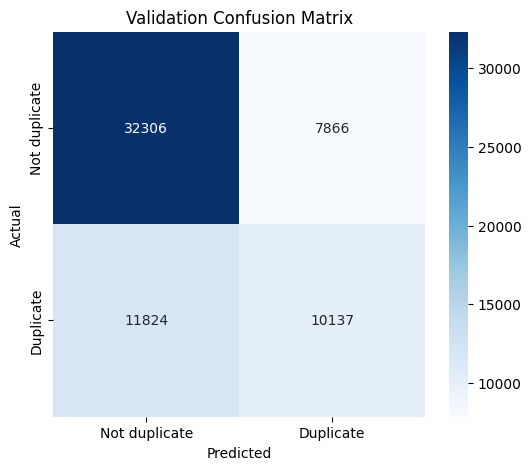


Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.80      0.77     40172
           1       0.56      0.46      0.51     21961

    accuracy                           0.68     62133
   macro avg       0.65      0.63      0.64     62133
weighted avg       0.67      0.68      0.67     62133



{'log_loss': 0.6911303516216574,
 'roc_auc': 0.7004391521267076,
 'f1_score': 0.5073065759183265,
 'inference_time': 0.008531800005584955}

In [32]:
classify_analysis(y_train_nosw, X_train_nosw, best_model_nosw, 'Training')
classify_analysis(y_val_nosw, X_val_nosw, best_model_nosw, 'Validation')

#### Error analysis

In [33]:
train_errors_nosw = error_analysis(train_df_nosw, X_train_nosw, best_model_nosw)

print("False Positive training examples")
display(train_errors_nosw["fp"].head())

print("False Negative training examples")
display(train_errors_nosw["fn"].head())

Error Analysis
TP : 94619
TN : 156409
FP : 7433
FN : 2835
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[best, place, reside, india]","[ia, best, place, visit, india]",3,0.500,0.750000,1,9,best place reside india,ia best place visit india,0.225184,1,0.622754
20,197537,65750,How do I download free movies from torrent?,How do I download from torrent?,0,train,"[download, free, movie, torrent]","[download, torrent]",2,0.500,1.000000,2,12,download free movie torrent,download torrent,0.347061,1,0.503338
83,72064,72065,Did India won a single medal in Rio Olympics 2...,How many medals did India won in Olympic 2016?,0,train,"[india, single, medal, rio, olympics, 2016]","[many, medal, india, olympic, 2016]",3,0.375,0.600000,1,4,india single medal rio olympics 2016,many medal india olympic 2016,0.150594,1,0.575431
106,28858,343001,Do atheists believe in ghosts?,Do theists believe in ghosts?,0,train,"[atheist, believe, ghost]","[theist, believe, ghost]",2,0.500,0.666667,0,1,atheist believe ghost,theist believe ghost,0.630350,1,0.647708
180,68946,143537,What happens if there is suspicious activity o...,How would I know if there's been suspicious ac...,0,train,"[happen, suspicious, activity, instagram]","[would, know, suspicious, activity, instagram]",3,0.500,0.750000,1,8,happen suspicious activity instagram,would know suspicious activity instagram,0.670216,1,0.594153


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
175,426865,310304,What is language?,What defines a language?,1,train,[language],"[define, language]",1,0.500000,1.0,1,7,language,define language,0.579502,0,0.438312
181,446830,257938,What are rent averages in New York City by bor...,What are the rent averages in New York City by...,1,train,"[rent, average, new, york, city, borough, 2014]","[rent, average, new, york, city, borough, 2014]",7,1.000000,1.0,0,4,rent average new york city borough 2014,rent average new york city borough 2014,1.000000,0,0.461455
204,255732,235075,How do I dissolve silicon?,Does anything dissolve silicon?,1,train,"[dissolve, silicon]","[anything, dissolve, silicon]",2,0.666667,1.0,1,5,dissolve silicon,anything dissolve silicon,0.876362,0,0.498202
221,210613,210614,How do you define health?,How do we define health?,1,train,"[define, health]","[define, health]",2,1.000000,1.0,0,1,define health,define health,1.000000,0,0.361299
235,266462,431465,How can I get a PhD quickly?,How can I get a PhD?,1,train,"[get, phd, quickly]","[get, phd]",2,0.666667,1.0,1,8,get phd quickly,get phd,0.878240,0,0.382241


In [34]:
val_errors_nosw = error_analysis(val_df_nosw, X_val_nosw, best_model_nosw)

print("False Positive validation examples")
display(val_errors_nosw["fp"].head())

print("False Negative validation examples")
display(val_errors_nosw["fn"].head())

Error Analysis
TP : 10137
TN : 32306
FP : 7866
FN : 11824
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
5,45508,303505,When did you join Quora?,Why did I join Quora?,0,val,"[join, quora]","[join, quora]",2,1.000000,1.000000,0,3,join quora,join quora,1.000000,1,0.912160
20,346197,537204,What is the mileage of Royal Enfield Himalayan...,Which handlebar will be most comfortable for l...,0,val,"[mileage, royal, enfield, himalayan, city]","[handlebar, comfortable, long, ride, royal, en...",3,0.333333,0.600000,2,28,mileage royal enfield himalayan city,handlebar comfortable long ride royal enfield ...,0.672154,1,0.878965
38,211946,385629,Do Indian girls ever give lifts to boys?,Do Indian men like curvy girls only?,0,val,"[indian, girl, ever, give, lift, boys]","[indian, men, like, curvy, girl]",2,0.222222,0.400000,1,4,indian girl ever give lift boys,indian men like curvy girl,0.112065,1,0.632919
43,483191,225770,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0,val,"[like, live, israeli, settlement]","[like, live, israeli, settlement, west, bank]",4,0.666667,1.000000,2,17,like live israeli settlement,like live israeli settlement west bank,0.728837,1,0.860134
44,358687,358688,What does Nelson Mandela mean to you?,What was Nelson Mandela like in person?,0,val,"[nelson, mandela, mean]","[nelson, mandela, like, person]",2,0.400000,0.666667,1,2,nelson mandela mean,nelson mandela like person,0.835862,1,0.703954


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,"[open, ppf, account, benefit]","[ppf, account]",2,0.500000,1.000000,2,36,open ppf account benefit,ppf account,0.642243,0,0.177963
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"[sahara, average, temperatures, compare, one, ...","[sahara, average, temperatures, compare, one, ...",5,0.625000,0.833333,1,3,sahara average temperatures compare one antarc...,sahara average temperatures compare one gibson...,0.527260,0,0.010590
3,26893,83712,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1,val,"[late, learn, piano]","[late, learn, play, piano, 26]",3,0.600000,1.000000,2,13,late learn piano,late learn play piano 26,0.590149,0,0.458894
10,356289,356290,What is a submersible pump? What purpose does ...,What is a submersible pump?,1,val,"[submersible, pump, purpose, serve]","[submersible, pump]",2,0.500000,1.000000,2,28,submersible pump purpose serve,submersible pump,0.523271,0,0.368835
18,179589,219828,Which is best choice for newbies Honda hornet ...,I am looking to buy new bike. Suzuki gixxer 15...,1,val,"[best, choice, newbie, honda, hornet, 160r, su...","[look, buy, new, bike, suzuki, gixxer, 155, ho...",6,0.428571,0.666667,3,15,best choice newbie honda hornet 160r suzuki gi...,look buy new bike suzuki gixxer 155 honda horn...,0.666464,0,0.037445


# TF-IDF + SVD

## With stopwords

### Data Loading

In [4]:
train_df_sw_svd = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_sw_tf_idf_svd.parquet")
val_df_sw_svd = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_sw_tf_idf_svd.parquet")

train_df_sw_svd.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_90,q2_svd_91,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,"[what, be, practical, management, and, what, b...","[what, be, the, practical, aspect, of, strateg...",5,0.555556,...,0.002771,-0.000996,-0.000210,-0.011027,0.003078,-0.002213,-0.004684,0.000260,-0.008821,0.003365
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,"[how, useful, be, makeuseof, answer]","[be, there, any, q, a, site, that, be, not, ya...",2,0.117647,...,-0.000813,0.014216,-0.013116,-0.002396,0.022425,-0.016162,-0.015395,0.021079,0.012554,0.003694
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[which, be, the, best, place, to, reside, in, ...","[which, ia, the, best, place, to, visit, in, i...",7,0.538462,...,-0.006432,0.017445,0.014441,0.086373,-0.045393,0.026737,0.024533,-0.005883,-0.012869,-0.015971


### Design matrix and target

In [5]:
X_train_sw_svd = train_df_sw_svd.drop(columns=DROP_COLUMNS)
X_val_sw_svd = val_df_sw_svd.drop(columns=DROP_COLUMNS)
X_train_sw_svd = X_train_sw_svd.fillna(0)
X_val_sw_svd = X_val_sw_svd.fillna(0)

X_train_sw_svd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261296 entries, 0 to 261295
Columns: 206 entries, common_word_count to q2_svd_99
dtypes: float64(203), int64(3)
memory usage: 410.7 MB


In [6]:
y_train_sw_svd = train_df_sw_svd['is_duplicate']
y_val_sw_svd = val_df_sw_svd['is_duplicate']

y_train_sw_svd.info()

<class 'pandas.core.series.Series'>
RangeIndex: 261296 entries, 0 to 261295
Series name: is_duplicate
Non-Null Count   Dtype
--------------   -----
261296 non-null  int64
dtypes: int64(1)
memory usage: 2.0 MB


### Basic Model

In [43]:
model_sw_svd = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='liblinear'
)

In [44]:
train_model(model_sw_svd, X_train_sw_svd, y_train_sw_svd)

Training time: 25.12 seconds


(LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'),
 25.1242122000549)

#### Evaluation

Training
Log Loss      : 0.5041
ROC-AUC       : 0.8110
F1-score      : 0.6061
Inference time: 0.3164 s


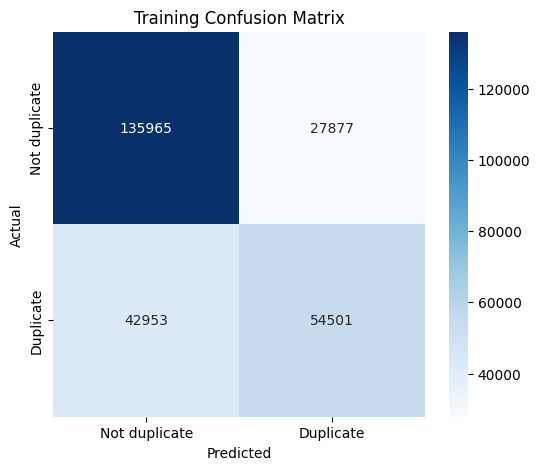


Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.83      0.79    163842
           1       0.66      0.56      0.61     97454

    accuracy                           0.73    261296
   macro avg       0.71      0.69      0.70    261296
weighted avg       0.72      0.73      0.72    261296

Validation
Log Loss      : 0.5147
ROC-AUC       : 0.7944
F1-score      : 0.5572
Inference time: 0.0881 s


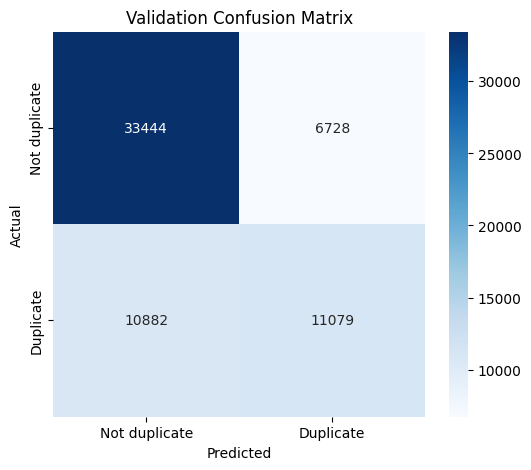


Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.83      0.79     40172
           1       0.62      0.50      0.56     21961

    accuracy                           0.72     62133
   macro avg       0.69      0.67      0.67     62133
weighted avg       0.71      0.72      0.71     62133



{'log_loss': 0.5146667382417022,
 'roc_auc': 0.7943938441868581,
 'f1_score': 0.5571816535908268,
 'inference_time': 0.08809869992546737}

In [45]:
classify_analysis(y_train_sw_svd, X_train_sw_svd, model_sw_svd, 'Training')
classify_analysis(y_val_sw_svd, X_val_sw_svd, model_sw_svd, 'Validation')

#### Error Analysis

In [46]:
train_errors_sw_svd = error_analysis(train_df_sw_svd, X_train_sw_svd, model_sw_svd)

print("False Positive training examples")
display(train_errors_sw_svd["fp"].head())

print("False Negative training examples")
display(train_errors_sw_svd["fn"].head())

Error Analysis
TP : 54501
TN : 135965
FP : 27877
FN : 42953
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[which, be, the, best, place, to, reside, in, ...","[which, ia, the, best, place, to, visit, in, i...",7,0.538462,...,0.014441,0.086373,-0.045393,0.026737,0.024533,-0.005883,-0.012869,-0.015971,1,0.852053
5,425388,425389,Why do people avoid south facing homes?,"Why is a ""south facing"" home so important to s...",0,train,"[why, do, people, avoid, south, facing, home]","[why, be, a, south, facing, home, so, importan...",5,0.384615,...,0.006497,-0.006225,0.014825,0.017546,0.004271,-0.008134,0.014262,-0.020504,1,0.617264
20,197537,65750,How do I download free movies from torrent?,How do I download from torrent?,0,train,"[how, do, i, download, free, movie, from, torr...","[how, do, i, download, from, torrent]",6,0.750000,...,-0.033029,-0.020804,0.049569,-0.034298,0.012469,0.023319,0.011773,0.001983,1,0.611439
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,"[which, language, do, you, think, be, the, mos...","[which, be, the, most, difficult, language, of...",7,0.466667,...,0.015119,-0.013738,-0.016487,0.008513,0.012628,0.048308,-0.020399,0.017289,1,0.779859
47,258350,258351,Why is making money online is difficult?,Is making money online real?,0,train,"[why, be, make, money, online, be, difficult]","[be, make, money, online, real]",4,0.571429,...,-0.048215,0.013518,0.001100,-0.007600,-0.009029,-0.010212,-0.014826,-0.005819,1,0.724583


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
3,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,train,"[why, do, so, many, people, ask, question, on,...","[why, do, not, many, people, post, question, o...",9,0.281250,...,-0.001361,0.018113,0.000566,0.005487,-0.004096,-0.046182,-0.002762,0.009809,0,0.355794
7,176809,185587,What is the best small business to start in Na...,Which business/startup should I start in Nagpu...,1,train,"[what, be, the, best, small, business, to, sta...","[which, business, startup, should, i, start, i...",5,0.263158,...,0.009370,0.019550,0.029969,-0.015859,-0.006786,0.007761,-0.003624,-0.007888,0,0.263143
21,237270,144610,What is the evolutionary explanation for the e...,What's the evolutionary reason for the hymen?,1,train,"[what, be, the, evolutionary, explanation, for...","[what, be, the, evolutionary, reason, for, the...",6,0.600000,...,0.005604,0.010498,-0.006164,-0.004525,0.008704,-0.015467,0.003252,-0.001434,0,0.399641
31,114980,114981,What are the prerequisites for studying Finite...,What are the mathematical prerequisites for un...,1,train,"[what, be, the, prerequisite, for, study, fini...","[what, be, the, mathematical, prerequisite, fo...",8,0.615385,...,-0.000160,0.000170,-0.003494,-0.002052,0.006993,0.000182,0.005842,-0.002597,0,0.401615
32,36500,57154,What is the meaning of love?,What is the exact meaning of love?,1,train,"[what, be, the, meaning, of, love]","[what, be, the, exact, meaning, of, love]",6,0.857143,...,0.010825,0.007006,0.061918,0.004671,-0.054300,0.000026,0.015693,-0.018976,0,0.490044


In [47]:
val_errors_sw_svd = error_analysis(val_df_sw_svd, X_val_sw_svd, model_sw_svd)

print("False Positive validation examples")
display(val_errors_sw_svd["fp"].head())

print("False Negative validation examples")
display(val_errors_sw_svd["fn"].head())

Error Analysis
TP : 11079
TN : 33444
FP : 6728
FN : 10882
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
5,45508,303505,When did you join Quora?,Why did I join Quora?,0,val,"[when, do, you, join, quora]","[why, do, i, join, quora]",3,0.428571,...,0.003097,0.013836,-0.015454,-0.037914,0.007238,0.015433,-0.041416,0.019768,1,0.507755
15,479269,479270,What are some non-capital goods?,What are capital goods?,0,val,"[what, be, some, non, capital, good]","[what, be, capital, good]",4,0.666667,...,0.004489,0.003325,-0.001381,0.011212,0.008991,-0.000684,0.011355,-0.007293,1,0.589019
34,262729,262730,Is it possible to see who last accessed or vie...,Possible to see who is watching you live on fa...,0,val,"[be, it, possible, to, see, who, last, access,...","[possible, to, see, who, be, watch, you, live,...",7,0.411765,...,-0.022563,-0.017226,-0.005854,0.026377,0.036729,0.019920,0.031122,0.016256,1,0.542265
42,96722,97875,Which is a good solar panel installation provi...,Which is a good solar panel installation provi...,0,val,"[which, be, a, good, solar, panel, installatio...","[which, be, a, good, solar, panel, installatio...",10,0.666667,...,0.007470,0.011219,-0.003363,0.008643,0.013821,-0.001829,0.006417,0.004848,1,0.507766
54,378046,378047,League of Legends: What should one know about ...,League of Legends: What should one know about ...,0,val,"[league, of, legend, what, should, one, know, ...","[league, of, legend, what, should, one, know, ...",11,0.733333,...,-0.001004,0.006507,-0.011837,-0.008914,0.038228,0.008173,-0.001123,0.010454,1,0.689327


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"[what, be, the, sahara, and, how, do, the, ave...","[what, be, the, sahara, and, how, do, the, ave...",14,0.823529,...,0.007419,0.047614,-0.007636,0.039346,-0.003118,-0.025965,0.021623,-0.007125,0,0.472974
3,26893,83712,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1,val,"[when, be, it, too, late, to, learn, piano]","[be, it, too, late, to, learn, to, play, the, ...",7,0.583333,...,-0.000789,0.001780,-0.002749,-0.003043,0.014790,-0.010714,-0.001687,0.024697,0,0.491892
9,220341,22484,Which books are best for each subject while pr...,What are the best books for UGC NET commerce?,1,val,"[which, book, be, best, for, each, subject, wh...","[what, be, the, best, book, for, ugc, net, com...",7,0.500000,...,0.005009,0.003579,-0.009283,-0.005931,-0.004498,-0.007658,-0.000824,-0.008241,0,0.418847
10,356289,356290,What is a submersible pump? What purpose does ...,What is a submersible pump?,1,val,"[what, be, a, submersible, pump, what, purpose...","[what, be, a, submersible, pump]",5,0.555556,...,0.005668,0.008335,-0.007326,0.006139,0.010550,-0.006557,-0.003367,-0.006993,0,0.459037
11,306530,94950,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,1,val,"[can, i, use, this, number, 1800, 251, 4919, b...","[what, be, belkin, router, tech, support, s, p...",5,0.294118,...,0.019146,0.005553,-0.026382,0.035009,0.039989,-0.062655,0.034065,0.049156,0,0.067194


### Model using RandomizedSearchCV

In [7]:
search_sw_svd = RandomizedSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=2
)

In [ ]:
train_model(search_sw_svd, X_train_sw_svd, y_train_sw_svd)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\ADMIN\ml_projects_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ..........C=100, class_weight=balanced, solver=saga; total time=16.8min


In [ ]:
best_params_sw_svd = search_sw_svd.best_params_
print(best_params_sw_svd)

In [ ]:
print(search_sw_svd.best_score_)

In [ ]:
best_model_sw_svd = search_sw_svd.best_estimator_

In [ ]:
joblib.dump(best_model_sw_svd, f"{MODEL_PATH}/best_logistic_model_sw_svd.joblib")

#### Evaluation

In [ ]:
classify_analysis(y_train_sw_svd, X_train_sw_svd, best_model_sw_svd, 'Training')
classify_analysis(y_val_sw_svd, X_val_sw_svd, best_model_sw_svd, 'Validation')

#### Error analysis

In [ ]:
train_errors_sw_svd_opt = error_analysis(train_df_sw_svd, X_train_sw_svd, best_model_sw_svd)

print("False Positive training examples")
display(train_errors_sw_svd_opt["fp"].head())

print("False Negative training examples")
display(train_errors_sw_svd_opt["fn"].head())

In [ ]:
val_errors_sw_svd_opt = error_analysis(val_df_sw_svd, X_val_sw_svd, best_model_sw_svd)

print("False Positive validation examples")
display(val_errors_sw_svd_opt["fp"].head())

print("False Negative validation examples")
display(val_errors_sw_svd_opt["fn"].head())

## Without stopwords

### Data Loading

In [4]:
train_df_nosw_svd = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_nosw_tf_idf_svd.parquet")
val_df_nosw_svd = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_nosw_tf_idf_svd.parquet")

train_df_nosw_svd.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_90,q2_svd_91,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,"[practical, management, strategic, management]","[practical, aspect, strategic, management]",3,0.750000,...,0.001743,-0.000522,-0.001499,-0.001979,0.002011,-0.002562,-0.001081,-0.000625,0.002287,0.003682
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,"[useful, makeuseof, answer]","[q, site, yahoo, answer, hate, speech, allow]",1,0.111111,...,0.008866,0.027980,0.005359,-0.007625,0.000451,-0.004390,-0.029462,0.008413,-0.012811,-0.004550
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[best, place, reside, india]","[ia, best, place, visit, india]",3,0.500000,...,0.001344,-0.006568,0.007986,0.014433,-0.022673,0.018463,0.014379,-0.005300,0.004824,-0.020186


### Design matrix and target

In [10]:
X_train_nosw_svd = train_df_nosw_svd.drop(columns=DROP_COLUMNS)
X_val_nosw_svd = val_df_nosw_svd.drop(columns=DROP_COLUMNS)
X_train_nosw_svd = X_train_nosw_svd.fillna(0)
X_val_nosw_svd = X_val_nosw_svd.fillna(0)

X_train_nosw_svd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261296 entries, 0 to 261295
Columns: 206 entries, common_word_count to q2_svd_99
dtypes: float64(203), int64(3)
memory usage: 410.7 MB


In [6]:
y_train_nosw_svd = train_df_nosw_svd['is_duplicate']
y_val_nosw_svd = val_df_nosw_svd['is_duplicate']

y_train_nosw_svd.info()

<class 'pandas.core.series.Series'>
RangeIndex: 261296 entries, 0 to 261295
Series name: is_duplicate
Non-Null Count   Dtype
--------------   -----
261296 non-null  int64
dtypes: int64(1)
memory usage: 2.0 MB


### Basic Model

In [7]:
model_nosw_svd = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='liblinear'
)

In [11]:
train_model(model_nosw_svd, X_train_nosw_svd, y_train_nosw_svd)

Training time: 35.75 seconds


(LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'),
 35.74709870002698)

#### Evaluation

Training
Log Loss      : 0.4923
ROC-AUC       : 0.8225
F1-score      : 0.6318
Inference time: 0.4460 s


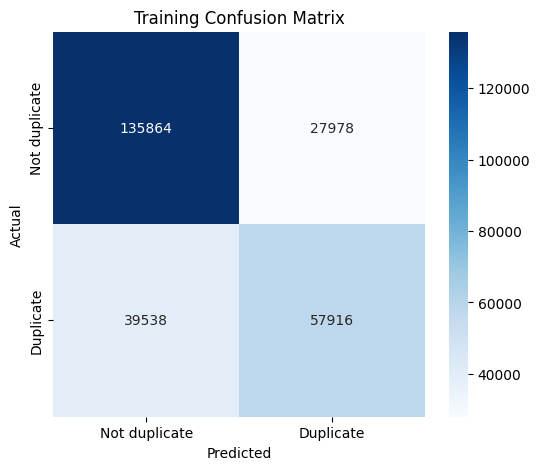


Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.83      0.80    163842
           1       0.67      0.59      0.63     97454

    accuracy                           0.74    261296
   macro avg       0.72      0.71      0.72    261296
weighted avg       0.74      0.74      0.74    261296

Validation
Log Loss      : 0.5174
ROC-AUC       : 0.7948
F1-score      : 0.5675
Inference time: 0.1066 s


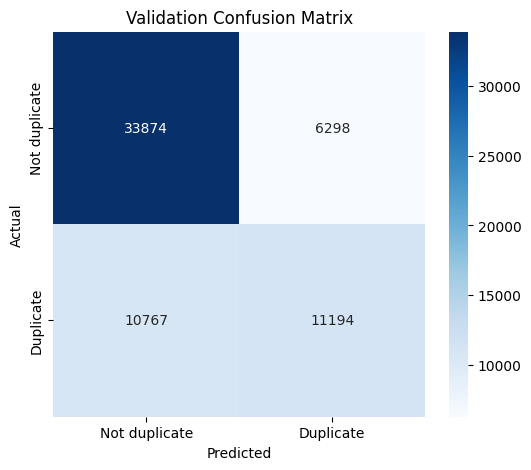


Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.84      0.80     40172
           1       0.64      0.51      0.57     21961

    accuracy                           0.73     62133
   macro avg       0.70      0.68      0.68     62133
weighted avg       0.72      0.73      0.72     62133



{'log_loss': 0.5174431977882523,
 'roc_auc': 0.7948108559631362,
 'f1_score': 0.5674600157149012,
 'inference_time': 0.1066063999896869}

In [12]:
classify_analysis(y_train_nosw_svd, X_train_nosw_svd, model_nosw_svd, 'Training')
classify_analysis(y_val_nosw_svd, X_val_nosw_svd, model_nosw_svd, 'Validation')

#### Error analysis

In [13]:
train_errors_nosw_svd = error_analysis(train_df_nosw_svd, X_train_nosw_svd, model_nosw_svd)

print("False Positive training examples")
display(train_errors_nosw_svd["fp"].head())

print("False Negative training examples")
display(train_errors_nosw_svd["fn"].head())

Error Analysis
TP : 57916
TN : 135864
FP : 27978
FN : 39538
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,"[practical, management, strategic, management]","[practical, aspect, strategic, management]",3,0.750000,...,-0.001499,-0.001979,0.002011,-0.002562,-0.001081,-0.000625,0.002287,0.003682,1,0.569086
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[best, place, reside, india]","[ia, best, place, visit, india]",3,0.500000,...,0.007986,0.014433,-0.022673,0.018463,0.014379,-0.005300,0.004824,-0.020186,1,0.713596
5,425388,425389,Why do people avoid south facing homes?,"Why is a ""south facing"" home so important to s...",0,train,"[people, avoid, south, facing, home]","[south, facing, home, important, people]",4,0.666667,...,-0.019736,0.082972,0.002719,0.022946,0.035689,-0.032038,0.016173,0.078623,1,0.611807
20,197537,65750,How do I download free movies from torrent?,How do I download from torrent?,0,train,"[download, free, movie, torrent]","[download, torrent]",2,0.500000,...,0.017382,0.016004,-0.015547,0.012277,-0.071643,-0.013342,-0.035892,-0.019960,1,0.576353
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,"[language, think, difficult, world]","[difficult, language, world]",3,0.750000,...,-0.009371,0.003593,-0.003044,-0.018806,-0.024298,-0.044513,-0.013801,-0.018147,1,0.907137


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
3,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,train,"[many, people, ask, question, quora, easily, a...","[many, people, post, question, quora, check, g...",5,0.294118,...,0.028975,-0.031191,-0.026575,0.021601,0.049008,-0.002874,0.040112,0.029171,0,0.325279
21,237270,144610,What is the evolutionary explanation for the e...,What's the evolutionary reason for the hymen?,1,train,"[evolutionary, explanation, existence, hymen]","[evolutionary, reason, hymen]",2,0.400000,...,0.002246,0.000170,-0.001452,0.001183,-0.001953,0.002983,-0.007530,-0.000868,0,0.353833
23,112697,112698,Is the human life more important than the life...,Do human lives have any more value than other ...,1,train,"[human, life, important, life, creature]","[human, life, value, animal, life]",2,0.333333,...,0.001718,0.007603,-0.017222,0.052390,-0.023347,-0.030154,-0.009654,0.053191,0,0.448372
27,370532,91966,What reasons would there be for Christopher Co...,Why was Christopher Columbus considered a vill...,1,train,"[reason, would, christopher, columbus, conside...","[christopher, columbus, consider, villain]",4,0.666667,...,0.001395,0.002058,0.001946,-0.000567,-0.001237,-0.000039,-0.001142,0.003145,0,0.457592
31,114980,114981,What are the prerequisites for studying Finite...,What are the mathematical prerequisites for un...,1,train,"[prerequisite, study, finite, element, method,...","[mathematical, prerequisite, understand, finit...",4,0.500000,...,0.002104,-0.000652,0.001715,0.000909,-0.001758,0.000428,0.001865,-0.000083,0,0.263231


In [14]:
val_errors_nosw_svd = error_analysis(val_df_nosw_svd, X_val_nosw_svd, model_nosw_svd)

print("False Positive validation examples")
display(val_errors_nosw_svd["fp"].head())

print("False Negative validation examples")
display(val_errors_nosw_svd["fn"].head())

Error Analysis
TP : 11194
TN : 33874
FP : 6298
FN : 10767
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
5,45508,303505,When did you join Quora?,Why did I join Quora?,0,val,"[join, quora]","[join, quora]",2,1.000000,...,-0.007151,0.002569,0.011842,0.009164,-0.007357,-0.010986,0.006346,0.012783,1,0.833870
28,94017,316021,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0,val,"[cause, itchy, scalp, without, dandruff]","[cause, itchy, scalp, dandruff]",4,0.800000,...,0.005934,-0.002452,-0.003304,0.000580,0.003311,0.004186,0.002009,-0.000946,1,0.601712
34,262729,262730,Is it possible to see who last accessed or vie...,Possible to see who is watching you live on fa...,0,val,"[possible, see, last, access, view, photo, fac...","[possible, see, watch, live, facebook]",3,0.333333,...,0.064361,-0.020651,0.051003,-0.032807,-0.034802,-0.005017,0.013403,0.079038,1,0.588900
43,483191,225770,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0,val,"[like, live, israeli, settlement]","[like, live, israeli, settlement, west, bank]",4,0.666667,...,-0.025455,-0.026012,-0.008017,-0.041820,-0.038155,0.016093,0.023070,0.001585,1,0.541080
65,81578,223898,How much does youtube pay per 1000 views?,Will YouTube pay $1 for 1000 views? Why am I n...,0,val,"[much, youtube, pay, per, 1000, view]","[youtube, pay, 1, 1000, view, get, revenue]",4,0.444444,...,-0.000637,-0.007211,-0.001993,0.018960,0.003726,-0.020999,-0.004900,-0.013813,1,0.524234


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
7,33502,31173,How do I get my picture to be different on Quora?,How do I use my picture as my profile picture ...,1,val,"[get, picture, different, quora]","[use, picture, profile, picture, quora]",2,0.333333,...,-0.003901,0.008110,0.007092,-0.002519,-0.002144,-0.012501,-0.000901,0.014332,0,0.347612
11,306530,94950,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,1,val,"[use, number, 1800, 251, 4919, belkin, router,...","[belkin, router, tech, support, phone, number]",5,0.454545,...,0.004979,0.002223,-0.023532,-0.040393,-0.048899,0.008014,0.079084,0.003508,0,0.131920
12,360478,202804,How do I find best online sites for watching T...,What websites do you use to watch TV shows?,1,val,"[find, best, online, site, watch, tv, show]","[websites, use, watch, tv, show]",3,0.333333,...,0.064799,-0.048460,-0.035845,0.011329,0.005134,-0.020266,0.043066,0.006851,0,0.280040
18,179589,219828,Which is best choice for newbies Honda hornet ...,I am looking to buy new bike. Suzuki gixxer 15...,1,val,"[best, choice, newbie, honda, hornet, 160r, su...","[look, buy, new, bike, suzuki, gixxer, 155, ho...",6,0.428571,...,0.011413,-0.017814,-0.006280,0.028850,-0.020057,-0.011868,-0.002157,0.014681,0,0.159301
21,1894,23107,Why is saltwater taffy candy imported in Austria?,Why is Saltwater taffy candy imported in Mongo...,1,val,"[saltwater, taffy, candy, import, austria]","[saltwater, taffy, candy, import, mongolia]",4,0.666667,...,-0.000043,-0.000055,0.001394,-0.000121,-0.000510,-0.000059,-0.000134,0.000711,0,0.386283


### Model using RandomizerSearch CV

In [ ]:
search_nosw_svd = RandomizedSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=2
)

In [ ]:
train_model(search_nosw_svd, X_train_nosw_svd, y_train_nosw_svd)

In [ ]:
best_params_nosw_svd = search_nosw_svd.best_params_
print(best_params_nosw_svd)

In [ ]:
print(search_nosw_svd.best_score_)

In [ ]:
best_model_nosw_svd = search_nosw_svd.best_estimator_

In [ ]:
joblib.dump(best_model_nosw_svd, f"{MODEL_PATH}/best_logistic_model_nosw_svd.joblib")

#### Evaluation

In [ ]:
classify_analysis(y_train_nosw_svd, X_train_nosw_svd, best_model_nosw_svd, 'Training')
classify_analysis(y_val_nosw_svd, X_val_nosw_svd, best_model_nosw_svd, 'Validation')

#### Error analysis

In [ ]:
train_errors_nosw_svd_opt = error_analysis(train_df_nosw_svd, X_train_nosw_svd, best_model_nosw_svd)

print("False Positive training examples")
display(train_errors_nosw_svd_opt["fp"].head())

print("False Negative training examples")
display(train_errors_nosw_svd_opt["fn"].head())

In [ ]:
val_errors_nosw_svd_opt = error_analysis(val_df_nosw_svd, X_val_nosw_svd, best_model_nosw_svd)

print("False Positive validation examples")
display(val_errors_nosw_svd_opt["fp"].head())

print("False Negative validation examples")
display(val_errors_nosw_svd_opt["fn"].head())

# Sentence Embeddings

## Sentence Embeddings - Model 1 ("all-mpnet-base-v2")

### Data Loading

In [4]:
train_df_se1 = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_se1.parquet")
val_df_se1 = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_se1.parquet")

train_df_se1.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0.828576,0.585532
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0.061228,1.370235
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0.729282,0.735823


In [5]:
train_emb_q1_se1 = np.load(f"{PROCESS_DATA_PATH}/embedding_se1_train_q1.npy")
train_emb_q2_se1 = np.load(f"{PROCESS_DATA_PATH}/embedding_se1_train_q2.npy")

val_emb_q1_se1 = np.load(f"{PROCESS_DATA_PATH}/embedding_se1_val_q1.npy")
val_emb_q2_se1 = np.load(f"{PROCESS_DATA_PATH}/embedding_se1_val_q2.npy")

### Design matrix and target

In [6]:
X_train_emb_se1 = np.hstack([train_emb_q1_se1, train_emb_q2_se1])
X_val_emb_se1 = np.hstack([val_emb_q1_se1, val_emb_q2_se1])

In [7]:
X_train_se1 = np.hstack([X_train_emb_se1, train_df_se1[EMBEDDING_FEATURES].to_numpy()])
X_val_se1 = np.hstack([X_val_emb_se1, val_df_se1[EMBEDDING_FEATURES].to_numpy()])

In [8]:
y_train_se_1 = train_df_se1["is_duplicate"].values
y_val_se_1  = val_df_se1["is_duplicate"].values

### Basic Model

In [9]:
model_se1 = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='liblinear'
)

In [10]:
train_model(model_se1, X_train_se1, y_train_se_1)

Training time: 295.95 seconds


(LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'),
 295.9524386000121)

#### Evaluation

Training
Log Loss      : 0.3143
ROC-AUC       : 0.9334
F1-score      : 0.8124
Inference time: 4.7256 s


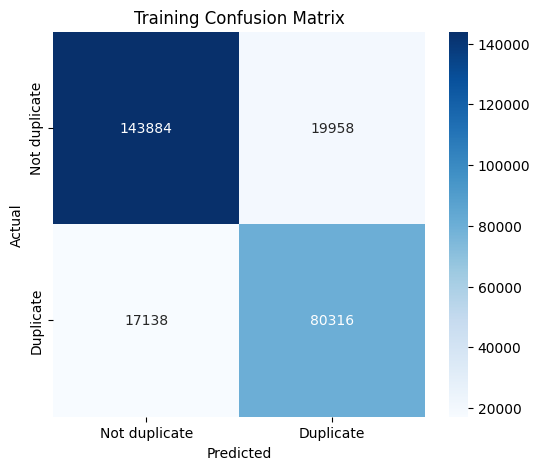


Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.89    163842
           1       0.80      0.82      0.81     97454

    accuracy                           0.86    261296
   macro avg       0.85      0.85      0.85    261296
weighted avg       0.86      0.86      0.86    261296

Validation
Log Loss      : 0.3385
ROC-AUC       : 0.9202
F1-score      : 0.7716
Inference time: 1.1599 s


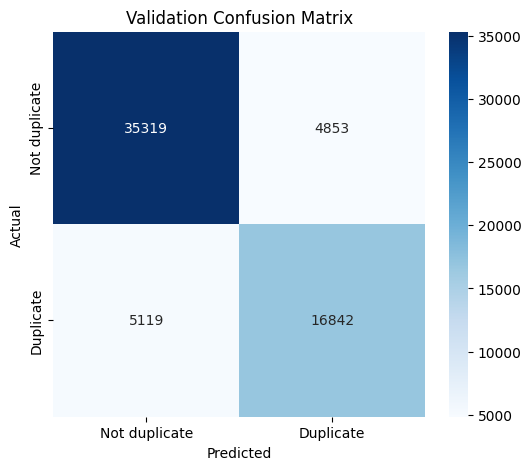


Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.88      0.88     40172
           1       0.78      0.77      0.77     21961

    accuracy                           0.84     62133
   macro avg       0.82      0.82      0.82     62133
weighted avg       0.84      0.84      0.84     62133



{'log_loss': 0.33852642281478756,
 'roc_auc': 0.9202066887167747,
 'f1_score': 0.7715777899945024,
 'inference_time': 1.1598705999786034}

In [11]:
classify_analysis(y_train_se_1, X_train_se1, model_se1, 'Training')
classify_analysis(y_val_se_1, X_val_se1, model_se1, 'Validation')

#### Error analysis

In [12]:
train_errors_se1 = error_analysis(train_df_se1, X_train_se1, model_se1)

print("False Positive training examples")
display(train_errors_se1["fp"].head())

print("False Negative training examples")
display(train_errors_se1["fn"].head())

Error Analysis
TP : 80316
TN : 143884
FP : 19958
FN : 17138
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
5,425388,425389,Why do people avoid south facing homes?,"Why is a ""south facing"" home so important to s...",0,train,Why do people avoid south facing homes?,"Why is a ""south facing"" home so important to s...",0.901452,0.443955,1,0.724852
9,181645,181646,Who do you think is the best singer that has e...,Who is the best singer of all time?,0,train,Who do you think is the best singer that has e...,Who is the best singer of all time?,0.870859,0.508215,1,0.675755
11,177898,177899,What can I do when I can't remember my Apple I...,"I forgot my Apple ID and Password, what should...",0,train,What can I do when I can't remember my Apple I...,"I forgot my Apple ID and Password, what should...",0.833500,0.577061,1,0.611819
20,197537,65750,How do I download free movies from torrent?,How do I download from torrent?,0,train,How do I download free movies from torrent?,How do I download from torrent?,0.829496,0.583959,1,0.624758
30,496361,124951,What are the disadvantages of hiring foreign w...,What are the advantages of hiring foreign work...,0,train,What are the disadvantages of hiring foreign w...,What are the advantages of hiring foreign work...,0.890581,0.467800,1,0.534029


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
44,110587,110588,What is the conclusive proof of the existence ...,What are black holes? Do they really exist? Ho...,1,train,What is the conclusive proof of the existence ...,What are black holes? Do they really exist? Ho...,0.641810,0.846392,0,0.355008
60,421632,421633,How is the master of data science program like...,What are the good universities offering data s...,1,train,How is the master of data science program like...,What are the good universities offering data s...,0.684569,0.794268,0,0.085262
65,31773,6887,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,1,train,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,0.534478,0.964906,0,0.008649
82,299018,383486,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,1,train,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,0.783701,0.657722,0,0.356458
96,2205,2206,Can I do meditation all day long? Does it help...,Does meditation really help in controlling tho...,1,train,Can I do meditation all day long? Does it help...,Does meditation really help in controlling tho...,0.615937,0.876429,0,0.122402


In [13]:
val_errors_se1 = error_analysis(val_df_se1, X_val_se1, model_se1)

print("False Positive validation examples")
display(val_errors_se1["fp"].head())

print("False Negative validation examples")
display(val_errors_se1["fn"].head())

Error Analysis
TP : 16842
TN : 35319
FP : 4853
FN : 5119
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
8,54140,299231,Which is best software course for a fresher to...,What are the best courses to get a good job in...,0,val,Which is best software course for a fresher to...,What are the best courses to get a good job in...,0.841260,0.563454,1,0.650985
28,94017,316021,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0,val,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0.926739,0.382782,1,0.653853
42,96722,97875,Which is a good solar panel installation provi...,Which is a good solar panel installation provi...,0,val,Which is a good solar panel installation provi...,Which is a good solar panel installation provi...,0.932783,0.366652,1,0.535401
43,483191,225770,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0,val,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0.943215,0.337001,1,0.590823
61,254415,254416,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0,val,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0.905712,0.434252,1,0.835134


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,How can I open a PPF account? And what are its...,What is PPF account?,0.813441,0.610834,0,0.405619
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",0.869866,0.510165,0,0.094723
11,306530,94950,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,1,val,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,0.777924,0.666447,0,0.330861
17,68233,102257,Which is the best way of living life?,What are some of the best examples of how to l...,1,val,Which is the best way of living life?,What are some of the best examples of how to l...,0.672122,0.809788,0,0.408158
21,1894,23107,Why is saltwater taffy candy imported in Austria?,Why is Saltwater taffy candy imported in Mongo...,1,val,Why is saltwater taffy candy imported in Austria?,Why is Saltwater taffy candy imported in Mongo...,0.874898,0.500204,0,0.296301


### Model using RandomizerSearch CV

In [9]:
search_se1 = RandomizedSearchCV(
    LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver="liblinear"
    ),
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    n_jobs=1,
    verbose=0,
    random_state=RANDOM_STATE,
    pre_dispatch=1
)

In [10]:
train_model(search_se1, X_train_se1, y_train_se_1)

Training time: 5138.55 seconds


c:\Users\ADMIN\ml_projects_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


(RandomizedSearchCV(cv=3,
                    estimator=LogisticRegression(max_iter=1000, random_state=42,
                                                 solver='liblinear'),
                    n_jobs=1,
                    param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001B53AA8E660>,
                                         'class_weight': [None, 'balanced'],
                                         'solver': ['lbfgs', 'saga',
                                                    'liblinear']},
                    pre_dispatch=1, random_state=42, scoring='f1'),
 5138.546924400027)

In [11]:
best_params_se1 = search_se1.best_params_
print(best_params_se1)

{'C': np.float64(1.2229467525390603), 'class_weight': 'balanced', 'solver': 'saga'}


In [12]:
print(search_se1.best_score_)

0.816226969804477


In [13]:
best_model_se1 = search_se1.best_estimator_

In [14]:
joblib.dump(best_model_se1, f"{MODEL_PATH}/best_logistic_model_se1.joblib")

['models/best_logistic_model_se1.joblib']

#### Evaluation

Training
Log Loss      : 0.3275
ROC-AUC       : 0.9333
F1-score      : 0.8205
Inference time: 0.3767 s


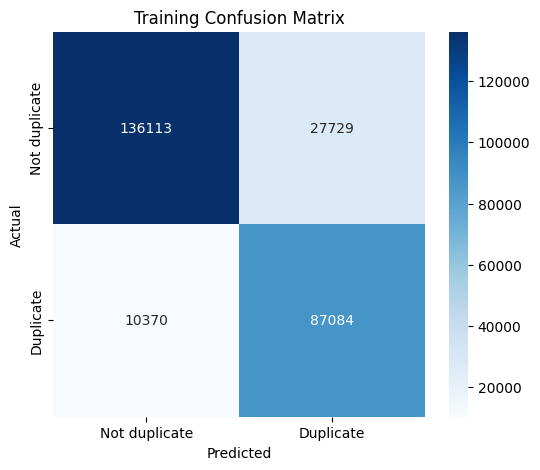


Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.83      0.88    163842
           1       0.76      0.89      0.82     97454

    accuracy                           0.85    261296
   macro avg       0.84      0.86      0.85    261296
weighted avg       0.87      0.85      0.86    261296

Validation
Log Loss      : 0.3488
ROC-AUC       : 0.9199
F1-score      : 0.7864
Inference time: 0.1985 s


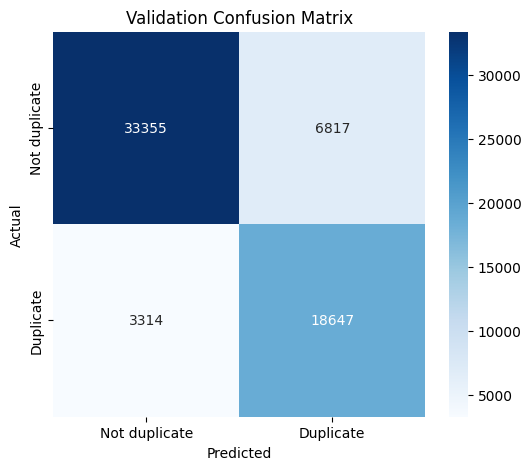


Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.83      0.87     40172
           1       0.73      0.85      0.79     21961

    accuracy                           0.84     62133
   macro avg       0.82      0.84      0.83     62133
weighted avg       0.85      0.84      0.84     62133



{'log_loss': 0.3488007479054574,
 'roc_auc': 0.919918421299772,
 'f1_score': 0.7863784923563522,
 'inference_time': 0.19846610003151}

In [15]:
classify_analysis(y_train_se_1, X_train_se1, best_model_se1, 'Training')
classify_analysis(y_val_se_1, X_val_se1, best_model_se1, 'Validation')

#### Error analysis

In [16]:
train_errors_se1_opt = error_analysis(train_df_se1, X_train_se1, best_model_se1)

print("False Positive training examples")
display(train_errors_se1_opt["fp"].head())

print("False Negative training examples")
display(train_errors_se1_opt["fn"].head())

Error Analysis
TP : 87084
TN : 136113
FP : 27729
FN : 10370
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0.828576,0.585532,1,0.557569
5,425388,425389,Why do people avoid south facing homes?,"Why is a ""south facing"" home so important to s...",0,train,Why do people avoid south facing homes?,"Why is a ""south facing"" home so important to s...",0.901452,0.443955,1,0.816882
9,181645,181646,Who do you think is the best singer that has e...,Who is the best singer of all time?,0,train,Who do you think is the best singer that has e...,Who is the best singer of all time?,0.870859,0.508215,1,0.763349
11,177898,177899,What can I do when I can't remember my Apple I...,"I forgot my Apple ID and Password, what should...",0,train,What can I do when I can't remember my Apple I...,"I forgot my Apple ID and Password, what should...",0.833500,0.577061,1,0.741829
20,197537,65750,How do I download free movies from torrent?,How do I download from torrent?,0,train,How do I download free movies from torrent?,How do I download from torrent?,0.829496,0.583959,1,0.750506


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
44,110587,110588,What is the conclusive proof of the existence ...,What are black holes? Do they really exist? Ho...,1,train,What is the conclusive proof of the existence ...,What are black holes? Do they really exist? Ho...,0.641810,0.846392,0,0.483864
60,421632,421633,How is the master of data science program like...,What are the good universities offering data s...,1,train,How is the master of data science program like...,What are the good universities offering data s...,0.684569,0.794268,0,0.128237
65,31773,6887,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,1,train,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,0.534478,0.964906,0,0.014294
82,299018,383486,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,1,train,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,0.783701,0.657722,0,0.458090
96,2205,2206,Can I do meditation all day long? Does it help...,Does meditation really help in controlling tho...,1,train,Can I do meditation all day long? Does it help...,Does meditation really help in controlling tho...,0.615937,0.876429,0,0.175642


In [17]:
val_errors_se1_opt = error_analysis(val_df_se1, X_val_se1, best_model_se1)

print("False Positive validation examples")
display(val_errors_se1_opt["fp"].head())

print("False Negative validation examples")
display(val_errors_se1_opt["fn"].head())

Error Analysis
TP : 18647
TN : 33355
FP : 6817
FN : 3314
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
8,54140,299231,Which is best software course for a fresher to...,What are the best courses to get a good job in...,0,val,Which is best software course for a fresher to...,What are the best courses to get a good job in...,0.841260,0.563454,1,0.778461
28,94017,316021,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0,val,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0.926739,0.382782,1,0.757237
42,96722,97875,Which is a good solar panel installation provi...,Which is a good solar panel installation provi...,0,val,Which is a good solar panel installation provi...,Which is a good solar panel installation provi...,0.932783,0.366652,1,0.664443
43,483191,225770,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0,val,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0.943215,0.337001,1,0.691896
47,124172,243591,Who is the most popular character in the Game ...,Who is the most underrated character in the Ga...,0,val,Who is the most popular character in the Game ...,Who is the most underrated character in the Ga...,0.809349,0.617497,1,0.590463


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",0.869866,0.510165,0,0.141776
11,306530,94950,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,1,val,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,0.777924,0.666447,0,0.475023
21,1894,23107,Why is saltwater taffy candy imported in Austria?,Why is Saltwater taffy candy imported in Mongo...,1,val,Why is saltwater taffy candy imported in Austria?,Why is Saltwater taffy candy imported in Mongo...,0.874898,0.500204,0,0.401013
24,247714,394432,"Are there any free online resources (courses, ...",Where can I do an online business analyst cert...,1,val,"Are there any free online resources (courses, ...",Where can I do an online business analyst cert...,0.695347,0.780581,0,0.163228
25,88306,84008,What do the scores on a classic IQ test mean?,What does actually IQ mean?,1,val,What do the scores on a classic IQ test mean?,What does actually IQ mean?,0.760095,0.692684,0,0.230606


## Sentence Embeddings - Model 2 ("BAAI/bge-base-en-v1.5")

### Data Loading

In [25]:
train_df_se2 = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_se2.parquet")
val_df_se2 = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_se2.parquet")

train_df_se2.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0.856630,0.535481
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0.518023,0.981811
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0.727708,0.737960


In [26]:
train_emb_q1_se2 = np.load(f"{PROCESS_DATA_PATH}/embedding_se2_train_q1.npy")
train_emb_q2_se2 = np.load(f"{PROCESS_DATA_PATH}/embedding_se2_train_q2.npy")

val_emb_q1_se2 = np.load(f"{PROCESS_DATA_PATH}/embedding_se2_val_q1.npy")
val_emb_q2_se2 = np.load(f"{PROCESS_DATA_PATH}/embedding_se2_val_q2.npy")

### Design matrix and target

In [27]:
X_train_emb_se2 = np.hstack([train_emb_q1_se2, train_emb_q2_se2])
X_val_emb_se2 = np.hstack([val_emb_q1_se2, val_emb_q2_se2])

In [28]:
X_train_se2 = np.hstack([X_train_emb_se2, train_df_se2[EMBEDDING_FEATURES].to_numpy()])
X_val_se2 = np.hstack([X_val_emb_se2, val_df_se2[EMBEDDING_FEATURES].to_numpy()])

In [29]:
y_train_se_2 = train_df_se2["is_duplicate"].values
y_val_se_2  = val_df_se2["is_duplicate"].values

### Basic Model

In [30]:
model_se2 = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='liblinear'
)

In [31]:
train_model(model_se2, X_train_se2, y_train_se_2)

Training time: 271.77 seconds


(LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'),
 271.77238540002145)

#### Evaluation

Training
Log Loss      : 0.3383
ROC-AUC       : 0.9229
F1-score      : 0.7923
Inference time: 3.3572 s


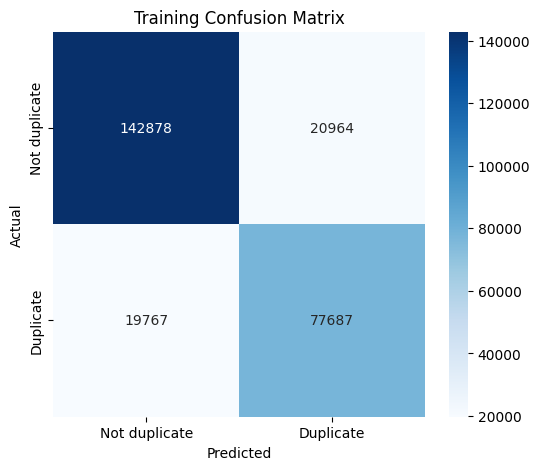


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.87      0.88    163842
           1       0.79      0.80      0.79     97454

    accuracy                           0.84    261296
   macro avg       0.83      0.83      0.83    261296
weighted avg       0.84      0.84      0.84    261296

Validation
Log Loss      : 0.3563
ROC-AUC       : 0.9117
F1-score      : 0.7556
Inference time: 1.1636 s


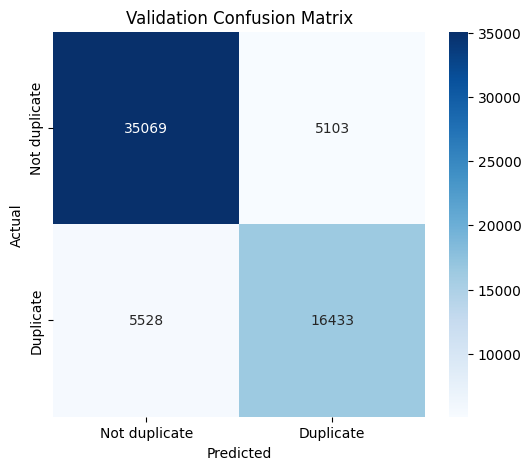


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.87      0.87     40172
           1       0.76      0.75      0.76     21961

    accuracy                           0.83     62133
   macro avg       0.81      0.81      0.81     62133
weighted avg       0.83      0.83      0.83     62133



{'log_loss': 0.3562882363129182,
 'roc_auc': 0.9117291712527439,
 'f1_score': 0.7555923397015886,
 'inference_time': 1.16359160002321}

In [32]:
classify_analysis(y_train_se_2, X_train_se2, model_se2, 'Training')
classify_analysis(y_val_se_2, X_val_se2, model_se2, 'Validation')

#### Error analysis

In [33]:
train_errors_se2 = error_analysis(train_df_se2, X_train_se2, model_se2)

print("False Positive validation examples")
display(train_errors_se2["fp"].head())

print("False Negative validation examples")
display(train_errors_se2["fn"].head())

Error Analysis
TP : 77687
TN : 142878
FP : 20964
FN : 19767
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
9,181645,181646,Who do you think is the best singer that has e...,Who is the best singer of all time?,0,train,Who do you think is the best singer that has e...,Who is the best singer of all time?,0.814195,0.609599,1,0.668191
11,177898,177899,What can I do when I can't remember my Apple I...,"I forgot my Apple ID and Password, what should...",0,train,What can I do when I can't remember my Apple I...,"I forgot my Apple ID and Password, what should...",0.865876,0.517926,1,0.511413
30,496361,124951,What are the disadvantages of hiring foreign w...,What are the advantages of hiring foreign work...,0,train,What are the disadvantages of hiring foreign w...,What are the advantages of hiring foreign work...,0.900721,0.445598,1,0.579896
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0.927325,0.381247,1,0.882266
49,432554,432555,What is the best book to read on investment st...,What are some good books on investment?,0,train,What is the best book to read on investment st...,What are some good books on investment?,0.881686,0.486444,1,0.716523


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
31,114980,114981,What are the prerequisites for studying Finite...,What are the mathematical prerequisites for un...,1,train,What are the prerequisites for studying Finite...,What are the mathematical prerequisites for un...,0.882827,0.484094,0,0.401648
37,56994,36776,How do I start learning C from basics to an ex...,What is the best way to start learning C langu...,1,train,How do I start learning C from basics to an ex...,What is the best way to start learning C langu...,0.788132,0.650950,0,0.252678
60,421632,421633,How is the master of data science program like...,What are the good universities offering data s...,1,train,How is the master of data science program like...,What are the good universities offering data s...,0.818853,0.601909,0,0.109264
65,31773,6887,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,1,train,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,0.728949,0.736276,0,0.154753
82,299018,383486,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,1,train,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,0.802834,0.627959,0,0.296207


In [34]:
val_errors_se2 = error_analysis(val_df_se2, X_val_se2, model_se2)

print("False Positive validation examples")
display(val_errors_se2["fp"].head())

print("False Negative validation examples")
display(val_errors_se2["fn"].head())

Error Analysis
TP : 16433
TN : 35069
FP : 5103
FN : 5528
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
4,353543,353544,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0,val,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0.843516,0.559436,1,0.565209
43,483191,225770,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0,val,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0.950732,0.313904,1,0.824855
47,124172,243591,Who is the most popular character in the Game ...,Who is the most underrated character in the Ga...,0,val,Who is the most popular character in the Game ...,Who is the most underrated character in the Ga...,0.852677,0.542813,1,0.624619
61,254415,254416,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0,val,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0.905137,0.435576,1,0.772614
65,81578,223898,How much does youtube pay per 1000 views?,Will YouTube pay $1 for 1000 views? Why am I n...,0,val,How much does youtube pay per 1000 views?,Will YouTube pay $1 for 1000 views? Why am I n...,0.874100,0.501797,1,0.654776


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,How can I open a PPF account? And what are its...,What is PPF account?,0.869970,0.509960,0,0.380301
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",0.857184,0.534445,0,0.229848
7,33502,31173,How do I get my picture to be different on Quora?,How do I use my picture as my profile picture ...,1,val,How do I get my picture to be different on Quora?,How do I use my picture as my profile picture ...,0.818979,0.601699,0,0.229814
11,306530,94950,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,1,val,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,0.851798,0.544430,0,0.325386
17,68233,102257,Which is the best way of living life?,What are some of the best examples of how to l...,1,val,Which is the best way of living life?,What are some of the best examples of how to l...,0.736357,0.726144,0,0.228841


**Observation:**
- TF-IDF + SVD outperforms raw TF-IDF across both stopword variants.
- Sentence embeddings are by far the strongest feature set for this model (val ROC-AUC ~0.92 vs. ~0.75-0.79 for TF-IDF-based features).
- RandomizedSearchCV tuning helps most on weaker feature sets (raw TF-IDF); its effect is marginal once sentence embeddings are used, since the default Logistic Regression is already close to its ceiling on that feature set.